In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>') 

/kaggle/input/competitions/mlp-kaggle-assignment-2-may-2026-term/sample_submission.csv
/kaggle/input/competitions/mlp-kaggle-assignment-2-may-2026-term/train.csv
/kaggle/input/competitions/mlp-kaggle-assignment-2-may-2026-term/test.csv


In [2]:
dfs = pd.read_csv("/kaggle/input/competitions/mlp-kaggle-assignment-2-may-2026-term/sample_submission.csv")
train = pd.read_csv("/kaggle/input/competitions/mlp-kaggle-assignment-2-may-2026-term/train.csv")
test = pd.read_csv("/kaggle/input/competitions/mlp-kaggle-assignment-2-may-2026-term/test.csv")

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style('whitegrid')

# 1. Data Types

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                90000 non-null  int64  
 1   customer_id       90000 non-null  int64  
 2   last_name         90000 non-null  object 
 3   credit_score      80444 non-null  float64
 4   country           83979 non-null  object 
 5   gender            90000 non-null  object 
 6   age               90000 non-null  float64
 7   tenure            90000 non-null  int64  
 8   acc_balance       82743 non-null  float64
 9   prod_count        85137 non-null  float64
 10  has_card          90000 non-null  float64
 11  is_active         90000 non-null  float64
 12  estimated_salary  90000 non-null  float64
 13  exit_status       90000 non-null  int64  
dtypes: float64(7), int64(4), object(3)
memory usage: 9.6+ MB


# 2. Descriptive Statistic 

In [5]:
num_cols = ['credit_score','age','tenure','acc_balance','prod_count','has_card','is_active','estimated_salary']
train[num_cols].describe().T[['min','25%','50%','mean','75%','max','std']]

,min,25%,50%,mean,75%,max,std
credit_score,350.00,597.00,659.00,656.497054,710.0000,850.00,80.016856
age,18.00,32.00,37.00,38.119533,42.0000,92.00,8.855203
tenure,0.00,3.00,5.00,5.017022,7.0000,10.00,2.804813
acc_balance,0.00,0.00,0.00,55456.732147,119825.7500,250898.09,62788.474236
prod_count,1.00,1.00,2.00,1.552932,2.0000,4.00,0.548011
has_card,0.00,1.00,1.00,0.754289,1.0000,1.00,0.430510
is_active,0.00,0.00,0.00,0.497178,1.0000,1.00,0.499995
estimated_salary,11.58,74430.36,117505.07,112394.659679,154874.7875,199992.48,50360.440702


# 3. Missing Values - Identification & Handling

In [6]:
missing = train.isnull().sum()
missing_estimate = train.isnull().mean()*100
pd.DataFrame({'missing_count': missing, 'missing_estimate': missing_estimate})[missing>0]

,missing_count,missing_estimate
credit_score,9556,10.617778
country,6021,6.690000
acc_balance,7257,8.063333
prod_count,4863,5.403333


# Strategy:
    * credit_score, acc_balance, prod_count (numerical): impute with the median, which is robust to the skew we saw above (especially for acc_balance).
    * country (categorical): impute with the mode (most frequent category).




In [7]:
credit_score_median = train['credit_score'].median()
acc_balance_median = train['acc_balance'].median()
prod_count_median = train['prod_count'].median()
country_mode = train['country'].mode()[0]

for df in [train, test]:
    df['credit_score'] = df['credit_score'].fillna(credit_score_median)
    df['acc_balance']  = df['acc_balance'].fillna(acc_balance_median)
    df['prod_count']   = df['prod_count'].fillna(prod_count_median)
    df['country']      = df['country'].fillna(country_mode)

print('Remaining missing values in train:', train.isnull().sum().sum())
print('Remaining missing values in test :', test.isnull().sum().sum())

Remaining missing values in train: 0
Remaining missing values in test : 0


In [8]:
test.isnull().sum()

id                  0
customer_id         0
last_name           0
credit_score        0
country             0
gender              0
age                 0
tenure              0
acc_balance         0
prod_count          0
has_card            0
is_active           0
estimated_salary    0
dtype: int64

# 4. Duplicates — Identification & Handling

In [9]:
print('Fully duplicated rows:', train.duplicated().sum())

#check the id part as per observation it shows the duplicate or repeted values
print('Rows with a repeated customer_id:', train.duplicated(subset=['customer_id'], keep=False).sum())
print('Unique customer_ids:', train['customer_id'].nunique(), 'out of', len(train), 'rows')


#check duplicates ignoring only the row id column (in case the same coustomer record was logged twice
#under different row id) -- run AFTER imputation, since two rows that differed only in an
# originally-missing field can become identical once that field is imputed with the same value

cols_no_id = [c for c in train.columns if c != 'id']
n_dupe_rows = train.duplicated(subset= cols_no_id , keep=False).sum()
print("Rows involved in a full duplicate (ignoring id)")
train[train.duplicated(subset=cols_no_id, keep=False)].sort_values(cols_no_id).head(8)

Fully duplicated rows: 0
Rows with a repeated customer_id: 82608
Unique customer_ids: 18247 out of 90000 rows
Rows involved in a full duplicate (ignoring id)


,id,customer_id,last_name,credit_score,country,gender,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,exit_status
1700,1700,15591248,Chukwumaobim,628.0,France,Female,29.0,9,71996.29,2.0,1.0,0.0,34857.46,0
11438,11438,15591248,Chukwumaobim,628.0,France,Female,29.0,9,71996.29,2.0,1.0,0.0,34857.46,0
32655,32655,15643487,Sal,630.0,France,Male,39.0,10,105473.74,1.0,0.0,0.0,58854.88,1
44677,44677,15643487,Sal,630.0,France,Male,39.0,10,105473.74,1.0,0.0,0.0,58854.88,1
39619,39619,15672798,O'Brien,656.0,France,Female,45.0,7,0.00,2.0,1.0,1.0,199392.14,0
41434,41434,15672798,O'Brien,656.0,France,Female,45.0,7,0.00,2.0,1.0,1.0,199392.14,0
40992,40992,15705657,Hewitt,535.0,France,Female,44.0,2,0.00,2.0,1.0,1.0,136330.26,0
68920,68920,15705657,Hewitt,535.0,France,Female,44.0,2,0.00,2.0,1.0,1.0,136330.26,0


 There are no rows that are fully duplicated including id (each id is unique by construction). customer_id also repeats frequently (only 18,247 unique IDs across 90,000 rows) — checking those rows shows they mostly have different last_name, credit_score, age, balances

However, ignoring only the id column, 8 rows (4 duplicate pairs) are identical across every other field.These are true duplicate customer records and should be dropped, keeping one copy of each.

In [10]:
before = len(train)
train = train.drop_duplicates(subset=cols_no_id, keep='first').reset_index(drop=True)
print(f'Dropped {before - len(train)} duplicate rows. New train shape: {train.shape}')

Dropped 4 duplicate rows. New train shape: (89996, 14)


## 5. Outliers — Identification & Handling

We use the IQR method (values beyond Q1 − 1.5×IQR or Q3 + 1.5×IQR) to flag outliers in each numerical column.

In [11]:
def iqr_outliers(s):
    q1,q3 = s.quantile([0.25,0.75])
    iqr = q3-q1
    lo , hi = q1-1.5*iqr , q3+1.5*iqr
    n_out = ((s<lo) | (s>hi)).sum()
    return lo,hi,n_out
# IQR is only meaningful for continuous/count variables -- has_card and is_active are binary
# flags where IQR degenerates (Q1==Q3), so we exclude them from this check
continuous_cols = ['credit_score','age','tenure','acc_balance','prod_count','estimated_salary']
for c in continuous_cols:
    lo, hi, n_out = iqr_outliers(train[c])
    print(f'{c:18s} bounds=[{lo:>10.1f}, {hi:>10.1f}]  outliers={n_out:>5d} ({100*n_out/len(train):.2f}%)')


credit_score       bounds=[     460.0,      852.0]  outliers=  605 (0.67%)
age                bounds=[      17.0,       57.0]  outliers= 3411 (3.79%)
tenure             bounds=[      -3.0,       13.0]  outliers=    0 (0.00%)
acc_balance        bounds=[ -174900.6,   291501.1]  outliers=    0 (0.00%)
prod_count         bounds=[      -0.5,        3.5]  outliers=  263 (0.29%)
estimated_salary   bounds=[  -46225.7,   275535.1]  outliers=    0 (0.00%)


**Decisions, column by column:**
- **`age`** has by far the most outliers (~3.8%, values above 57). These are real, plausible ages (up to 92) but the tail is long enough to affect distance/scale-sensitive models (KNN, Logistic Regression). We **cap (winsorize)** age at the IQR upper bound rather than dropping rows — this keeps all records while limiting the influence of extreme ages.
- **`credit_score`** now shows more IQR outliers than before imputation (median-imputing ~10.6% of rows tightened the IQR, pushing some previously-typical values just outside the new, narrower bounds). These are still genuine, valid credit scores (350–850 range) and not data-entry errors, so we **retain them as-is** rather than dropping/capping.
- **`prod_count`** outliers (~0.3%, values of 4 products) are legitimate discrete counts — a customer can hold 4 products — so we **retain them**.
- **`acc_balance`, `tenure`, `estimated_salary`** show ~0% IQR outliers — no action needed.
- **`has_card` and `is_active`** are binary flags — the IQR method isn't meaningful for them (it flags one of the two categories as "outlying" purely because it's the minority class), so we exclude them from outlier treatment entirely; class imbalance in a binary flag is not an outlier.

Net effect: only `age` is capped; nothing else is modified or dropped for outliers.

In [12]:
age_lo, age_hi = iqr_outliers(train['age'])[:2]
train['age'] = train['age'].clip(age_lo, age_hi)
test['age']  = test['age'].clip(age_lo, age_hi)
print(f'Age capped to [{age_lo}, {age_hi}]. New max age in train: {train["age"].max()}')

Age capped to [17.0, 57.0]. New max age in train: 57.0


## 6. Visualizations & Insights

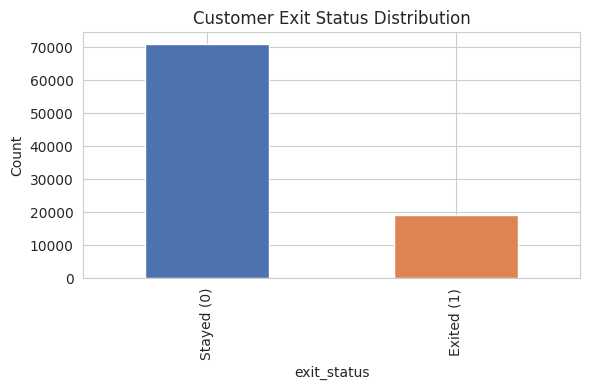

In [13]:
counts = train['exit_status'].value_counts().sort_index()

ax = counts.plot(
    kind='bar',
    figsize=(6, 4),
    color=['#4C72B0', '#DD8452']
)

ax.set_xticklabels(['Stayed (0)', 'Exited (1)'])
ax.set_title('Customer Exit Status Distribution')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

**Insight:** The target is imbalanced — 78.8% of customers stayed and 21.2% churned. This class imbalance means accuracy alone can be misleading; we track precision, recall, F1, and ROC-AUC for all models below, and consider `class_weight='balanced'` for some models.

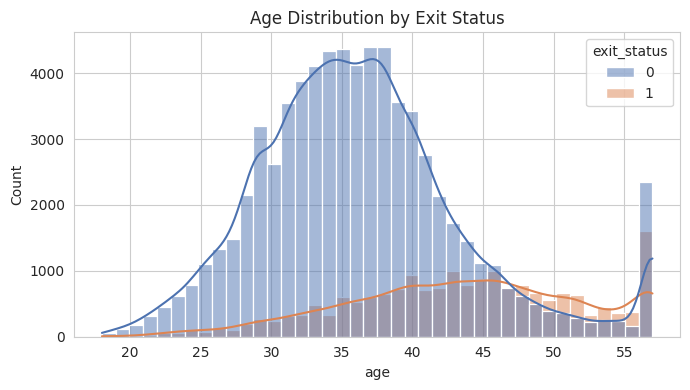

In [14]:
fig, ax = plt.subplots(figsize=(7,4))
sns.histplot(data=train, x='age', hue='exit_status', bins=40, kde=True, ax=ax, palette=['#4C72B0','#DD8452'])
ax.set_title('Age Distribution by Exit Status')
plt.tight_layout()
plt.show()

**Insight:** Churned customers (orange) skew noticeably older than retained customers (blue) — the churn distribution is centered around 40–50 years old versus ~30–35 for retained customers. `age` looks like one of the stronger predictors of churn.

Churn means a customer leaves/stops using the service.


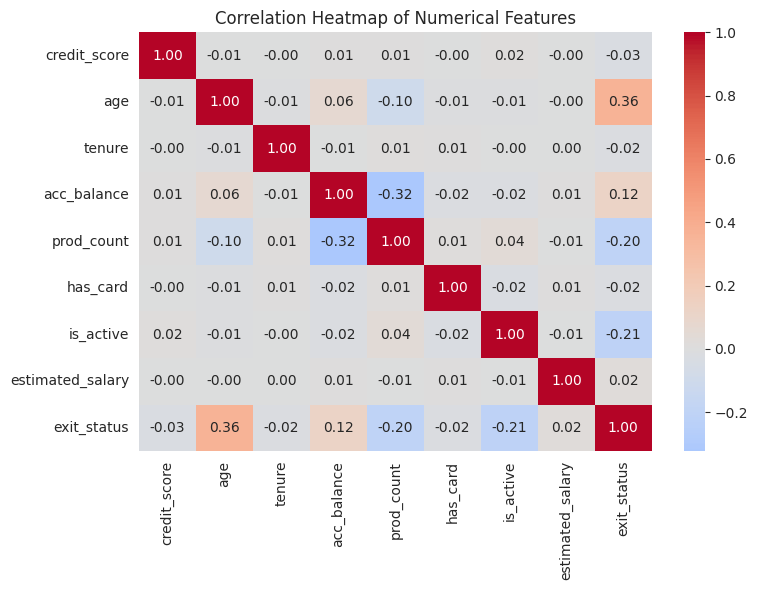

In [15]:
fig, ax = plt.subplots(figsize=(8,6))
corr = train[num_cols + ['exit_status']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

**Insight:** `age` (+0.36) has the strongest positive correlation with churn, followed by `acc_balance` (+0.12). `is_active` (−0.21) and `prod_count` (−0.20) are the strongest negative correlates — active customers with more products are less likely to churn. `credit_score`, `tenure`, `has_card`, and `estimated_salary` show almost no linear relationship with churn on their own.

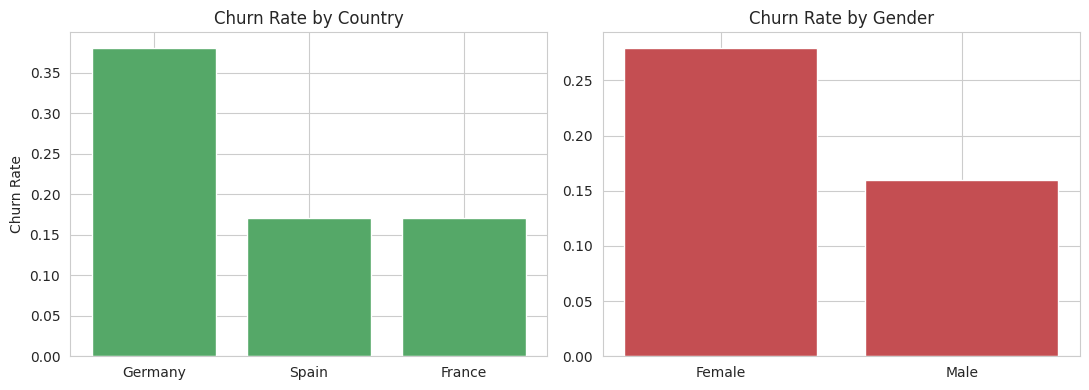

In [16]:
fig, axes = plt.subplots(1,2, figsize=(11,4))
country_rate = train.groupby('country')['exit_status'].mean().sort_values(ascending=False)
axes[0].bar(country_rate.index, country_rate.values, color='#55A868')
axes[0].set_title('Churn Rate by Country')
axes[0].set_ylabel('Churn Rate')
gender_rate = train.groupby('gender')['exit_status'].mean()
axes[1].bar(gender_rate.index, gender_rate.values, color='#C44E52')
axes[1].set_title('Churn Rate by Gender')
plt.tight_layout()
plt.show()

**Insight:** Germany has a visibly higher churn rate than France or Spain, suggesting `country` carries predictive signal despite showing no numeric correlation (it's categorical). Female customers churn somewhat more than male customers.

## 7. Feature Scaling & Encoding

In [17]:
drop_cols = ['id','customer_id','last_name']   # identifiers with no predictive value
X = train.drop(columns=drop_cols + ['exit_status'])
y = train['exit_status']
X_test_final = test.drop(columns=drop_cols)


from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train:', X_train.shape, ' Validation:', X_val.shape, ' Test (holdout):', X_test_final.shape)

Train: (71996, 10)  Validation: (18000, 10)  Test (holdout): (30000, 10)


**Decisions:**
- **`id`, `customer_id`, `last_name` are dropped** — pure identifiers/free text with no generalizable predictive signal and `last_name` would explode dimensionality if encoded.

In [18]:
X_train.columns

Index(['credit_score', 'country', 'gender', 'age', 'tenure', 'acc_balance',
       'prod_count', 'has_card', 'is_active', 'estimated_salary'],
      dtype='object')

In [19]:
cat_cols = ['country','gender']
num_cols_model = ['credit_score','age','tenure','acc_balance','prod_count','has_card','is_active','estimated_salary']


**Numerical features are scaled** with `StandardScaler` (zero mean, unit variance). This matters for distance-based and gradient-based models (KNN, Logistic Regression)

**Categorical features (`country`, `gender`) are one-hot encoded** (`drop='first'` to avoid the dummy-variable trap), since they have no ordinal relationship — one-hot encoding is appropriate rather than ordinal/label encoding.

**Binary flags `has_card`, `is_active`** are already 0/1 numeric and need no further encoding.

 Scaling parameters are fit on the training split only (via a `Pipeline` + `ColumnTransformer`) and applied to validation/test, preventing data leakage.

In [20]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols_model),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])
preprocess

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['credit_score', 'age', 'tenure',
                                  'acc_balance', 'prod_count', 'has_card',
                                  'is_active', 'estimated_salary']),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['country', 'gender'])])

## 8. Model Building

We train **8 different classification models**, all through the same `preprocess` pipeline (fit only on the training split) for a fair comparison:

1. Logistic Regression
2. K-Nearest Neighbors
3. Decision Tree
4. Random Forest
5. Support Vector Machine
6. AdaBoost
7. Neural Network (Multi-Layer Perceptron)
8. Gaussian Naive Bayes


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score 


models = {
    'Logistic Regression':    LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors':    KNeighborsClassifier(n_neighbors=15),
    'Decision Tree':          DecisionTreeClassifier(random_state=42, max_depth=8),
    'Random Forest':          RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'AdaBoost':                AdaBoostClassifier(n_estimators=150, random_state=42),
    # LinearSVC doesn't natively output probabilities, so it's wrapped in CalibratedClassifierCV
    'Support Vector Machine': CalibratedClassifierCV(LinearSVC(random_state=42, max_iter=2000, dual='auto'), cv=3),
    'Neural Network (MLP)':   MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=200, random_state=42, early_stopping=True),
    'Gaussian Naive Bayes':   GaussianNB(),
}

baseline_results = []
fitted_models = {}

for name, clf in models.items():
    pipe = Pipeline([('prep', preprocess), ('clf', clf)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_val)
    proba = pipe.predict_proba(X_val)[:, 1]
    baseline_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_val, pred),
        'Precision': precision_score(y_val, pred),
        'Recall': recall_score(y_val, pred),
        'F1': f1_score(y_val, pred),
        'ROC_AUC': roc_auc_score(y_val, proba)
    })
    fitted_models[name] = pipe

baseline_df = pd.DataFrame(baseline_results).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
baseline_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Neural Network (MLP),0.854833,0.726172,0.504069,0.595072,0.868506
1,AdaBoost,0.853556,0.738318,0.477028,0.579585,0.867924
2,Decision Tree,0.853556,0.715704,0.510895,0.596201,0.865668
3,Random Forest,0.849722,0.706278,0.496193,0.582884,0.862103
4,K-Nearest Neighbors,0.849000,0.711845,0.481229,0.574248,0.846410
5,Gaussian Naive Bayes,0.814389,0.575875,0.466264,0.515305,0.816926
6,Logistic Regression,0.832000,0.692119,0.371226,0.483254,0.814871
7,Support Vector Machine,0.831389,0.689706,0.369388,0.481108,0.814848
